c:\Users\Usuario\anaconda3\Lib\site-packages\pyogrio\raw.py:196: RuntimeWarning: D:/Infoamazonia/shapes/Bases/Desmatamento/desmatamento2008_2024.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_5292\150418653.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  desmatamento_buffer["area_ha"] = desmatamento_buffer.geometry.area / 10_000


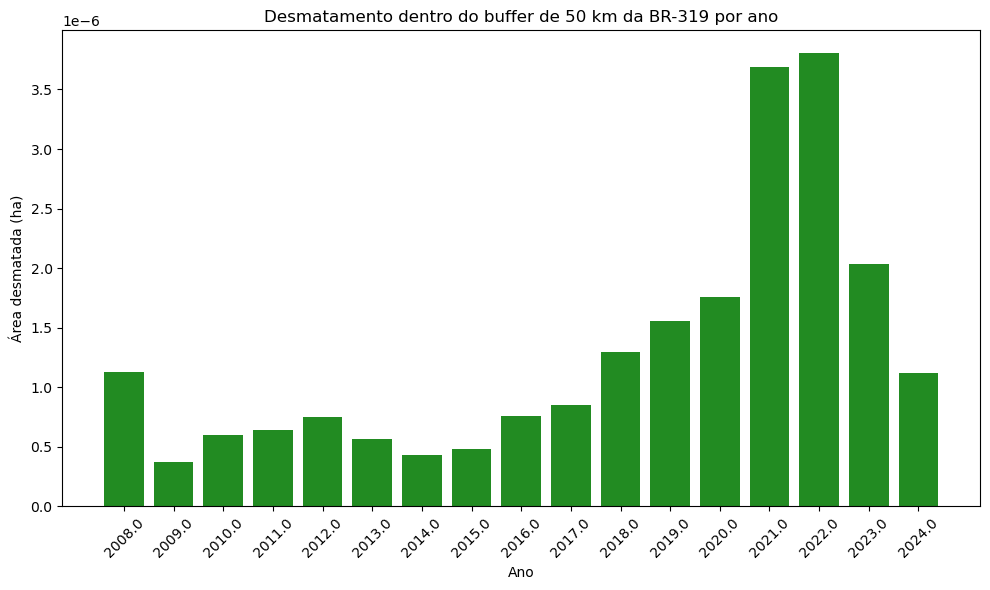

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Carregar os dados de desmatamento e o buffer da BR-319
desmatamento = gpd.read_file(r"D:/Infoamazonia/shapes/Bases/Desmatamento/desmatamento2008_2024.shp")  
buffer_gdf = gpd.read_file(r"D:/Infoamazonia/shapes/Bases/br319/BUFFER31950KM.geojson")

# Garantir que ambos os GeoDataFrames estejam no mesmo sistema de projeção (preferencialmente em metros, ex: EPSG:5880 ou 32720)
if desmatamento.crs != buffer_gdf.crs:
    buffer_gdf = buffer_gdf.to_crs(desmatamento.crs)

# Interseção: selecionar apenas o desmatamento dentro do buffer
desmatamento_buffer = gpd.overlay(desmatamento, buffer_gdf, how='intersection')

# Calcular área em hectares (1 ha = 10.000 m²)
# Supondo que a projeção seja em metros, senão deve-se reprojetar antes
desmatamento_buffer["area_ha"] = desmatamento_buffer.geometry.area / 10_000

# Agrupar por ano
# Certifique-se de que a coluna "year" está presente e tem o tipo correto
desmatamento_por_ano = desmatamento_buffer.groupby("year")["area_ha"].sum().reset_index()

# Plotar gráfico
plt.figure(figsize=(10, 6))
plt.bar(desmatamento_por_ano["year"].astype(str), desmatamento_por_ano["area_ha"], color="forestgreen")
plt.xlabel("Ano")
plt.ylabel("Área desmatada (ha)")
plt.title("Desmatamento dentro do buffer de 50 km da BR-319 por ano")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [2]:
desmatamento

,fid,state,path_row,main_class,class_name,sub_class,def_cloud,julian_day,image_date,year,area_km,scene_id,source,satellite,sensor,uuid,geometry
0,89,PA,021014,DESMATAMENTO,d2024,corte raso com solo exposto,0.0,216,2024-08-03,2024.0,0.489037,2547.0,Amazonia,Sentinel-2,MSI,d5f24255-d865-4ee7-a263-7b8fea5546a9,"POLYGON ((-55.03005 -8.0074, -55.03022 -8.0075..."
1,92,RO,012018,DESMATAMENTO,d2024,corte raso com solo exposto,0.0,210,2024-07-28,2024.0,1.381136,2291.0,Amazonia,Sentinel-2,MSI,58215b0c-d487-4b8d-809b-c99f28a4d58b,"POLYGON ((-64.14795 -12.28002, -64.14802 -12.2..."
2,117,MT,021016,DESMATAMENTO,d2024,corte raso com solo exposto,0.0,221,2024-08-08,2024.0,0.233037,2377.0,Amazonia,Sentinel-2,MSI,dfefa097-3ed9-48ad-a06f-cf9909ee2bd0,"POLYGON ((-54.65241 -9.77881, -54.65093 -9.778..."
3,179,AM,016013,DESMATAMENTO,d2024,corte raso com solo exposto,0.0,197,2024-07-15,2024.0,1.609665,2628.0,Amazonia,Sentinel-2,MSI,d1ad20f8-42cc-4f24-98fa-45992a9127f9,"POLYGON ((-59.817 -6.79498, -59.81676 -6.7949,..."
4,1,PA,024012,DESMATAMENTO,d2024,corte raso com solo exposto,0.0,218,2024-08-05,2024.0,0.020617,2189.0,Amazonia,Sentinel-2,MSI,dae0c56a-443b-4d3f-bc31-95256e45f101,"POLYGON ((-52.30452 -6.81512, -52.30452 -6.814..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796129,749661,RO,23267,DESMATAMENTO,d2023,desmatamento por degradação progressiva,0.0,211,2023-07-30,2023.0,0.083977,1779.0,Amazonia,Landsat,OLI,7cf6b640-850d-4b24-91e4-2e673cb01081,"POLYGON ((-64.10264 -10.33658, -64.10258 -10.3..."
796130,749662,PA,22664,DESMATAMENTO,d2023,corte raso com vegetação,0.0,233,2023-08-21,2023.0,1.811429,1852.0,Amazonia,Landsat,OLI,b2ebd034-2a73-4dcb-ab47-7bfd111d2fac,"POLYGON ((-53.68966 -6.45688, -53.68984 -6.457..."
796131,749663,RO,23167,DESMATAMENTO,d2023,corte raso com vegetação,0.0,212,2023-07-31,2023.0,0.097166,1775.0,Amazonia,Landsat,OLI,eebb9a21-247b-43b8-ac0d-c37d6bc190ee,"POLYGON ((-63.01023 -10.67575, -63.01002 -10.6..."
796132,749664,RO,23266,DESMATAMENTO,d2023,corte raso com vegetação,0.0,203,2023-07-22,2023.0,0.040081,1800.0,Amazonia,Landsat,OLI,eaa5ff04-6f56-49fd-a5dc-243fc5730c73,"POLYGON ((-63.10657 -8.97771, -63.10657 -8.977..."
